--- PHẦN 1: THỐNG KÊ ---
2     2.29
92    2.33
25    2.40
44    2.42
97    2.57
Name: DH1, dtype: float64
   GT KT   KV    DT   T1   DH1   DH2   DH3  US_TBM1  US_TBM2  US_TBM3 XL1 XL2  \
46  F  B    2  Kinh  8.1  6.09  2.10  2.47     8.38     7.16     8.14   Y   Y   
65  F  D    3  Kinh  9.2  6.44  2.17  5.55     7.39     7.41     6.19   G   K   
44  F  C    2  Kinh  7.6  2.42  2.28  5.98     8.52     9.15     7.31  TB   Y   
43  F  B    3  Kinh  6.6  9.47  2.48  7.70     5.22     8.89     7.18  XS  TB   
98  F  A    1  Kinh  6.5  3.25  2.50  2.04     7.69     6.14     5.70   G   G   
.. .. ..  ...   ...  ...   ...   ...   ...      ...      ...      ...  ..  ..   
61  M  A    2   Tày  6.3  8.47  8.59  2.67     6.97     9.39     7.24  TB   K   
80  M  C    2  Kinh  3.9  7.58  8.77  4.48     8.18     7.37     8.47  XS   Y   
6   M  C  2NT  Kinh  9.9  5.18  9.19  5.45     8.77     6.91     8.24   Y   Y   
82  M  C  2NT  Kinh  8.7  3.78  9.35  2.06     5.64     7.16     8.77   G   Y   
37 

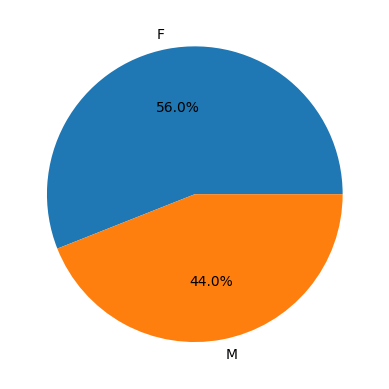

ValueError: Could not interpret value `Ketqua` for `hue`. An entry with this name does not appear in `data`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 0. Load dữ liệu
df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')

# --- BƯỚC CHUẨN BỊ: Tạo cột Ketqua (nếu file chưa có) ---
# Giả sử Đậu là tổng DH1+DH2+DH3 >= 15 (Bạn có thể sửa lại ngưỡng này)
df['Ketqua'] = np.where((df['DH1'] + df['DH2'] + df['DH3']) >= 15, 'Dau', 'Rot')

# --- PHẦN 1: THỐNG KÊ ---
print("--- PHẦN 1 ---")
print(df['DH1'].sort_values().head())
pt = df.pivot_table(index=['KT', 'KV', 'DT'], values='DH1', 
                    aggfunc=['count', 'sum', 'mean', 'median', 'min', 'max', 'std'])
print(pt)

# --- PHẦN 2 & 3: TRÌNH BÀY & TRỰC QUAN HÓA NHÓM ---
print("\n--- PHẦN 2 & 3 ---")
df['GT'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Biểu đồ GT')
plt.show()

sns.countplot(x='KV', hue='Ketqua', data=df)
plt.title('Biểu đồ Đậu/Rớt theo KV')
plt.show()

# --- PHẦN 4: TRỰC QUAN HÓA NÂNG CAO ---
print("\n--- PHẦN 4 ---")
def phanloai_t1(diem):
    if diem < 5: return 'Kem'
    elif diem < 7: return 'Trungbinh'
    elif diem < 8: return 'Kha'
    else: return 'Gioi'

df['phanlopt1'] = df['T1'].apply(phanloai_t1)
df['phanlopt1'] = pd.Categorical(df['phanlopt1'], categories=['Kem', 'Trungbinh', 'Kha', 'Gioi'], ordered=True)

# Multiple Line
df_grouped = df.groupby(['phanlopt1', 'T1']).size().reset_index(name='Count')
sns.lineplot(data=df_grouped, x='T1', y='Count', hue='phanlopt1', marker='o')
plt.title('Multiple Line: T1 theo phanlopt1')
plt.show()

# --- PHẦN 5: KHẢO SÁT PHÂN PHỐI & TƯƠNG QUAN ---
print("\n--- PHẦN 5 ---")
# Boxplot & Histogram
sns.histplot(df['T1'], kde=True)
plt.show()
sns.boxplot(x=df['T1'])
plt.show()

# QQ-Plot
sm.qqplot(df['T1'], line='s')
plt.title('QQ-Plot cho T1')
plt.show()

# Tương quan
corr = df[['DH1', 'DH2', 'DH3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
sns.pairplot(df[['DH1', 'DH2', 'DH3']])
plt.show()